In [1]:
import fitsio
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

fl_slow_movers = "/home/vwetzell/Documents/Sculptor/Sculptor_updated_3hlr_slow_movers.fits"
movers = fitsio.read(fl_slow_movers)

movers = movers[((5+movers["dof"])/2) > 10]
movers = movers[movers["g_mag"] > 10]

fl_slow_detections = "/home/vwetzell/Documents/Sculptor/Sculptor_updated_3hlr_slow_detections.fits"
detections = fitsio.read(fl_slow_detections)

fl_slow_cat = "/home/vwetzell/Documents/Sculptor/NEW_Sculptor_updated_3hlr.fits"
slow_cat = fitsio.read(fl_slow_cat)



In [2]:
movers.shape

(170501,)

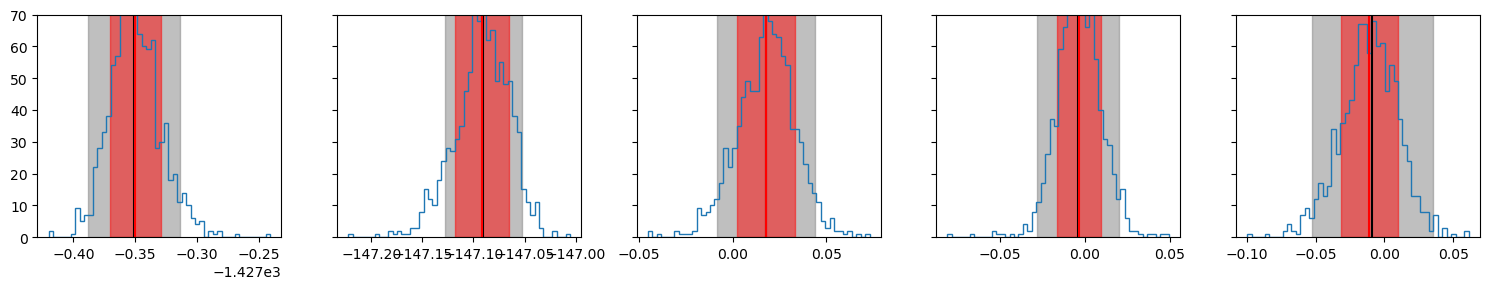

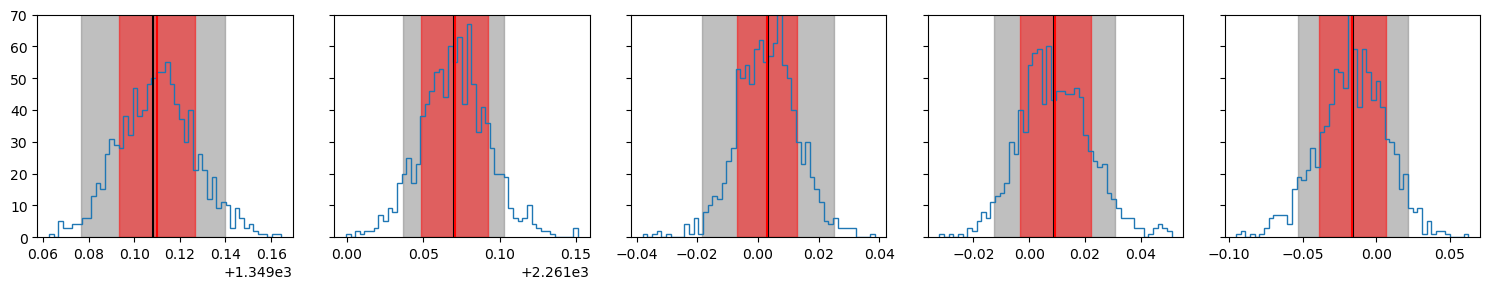

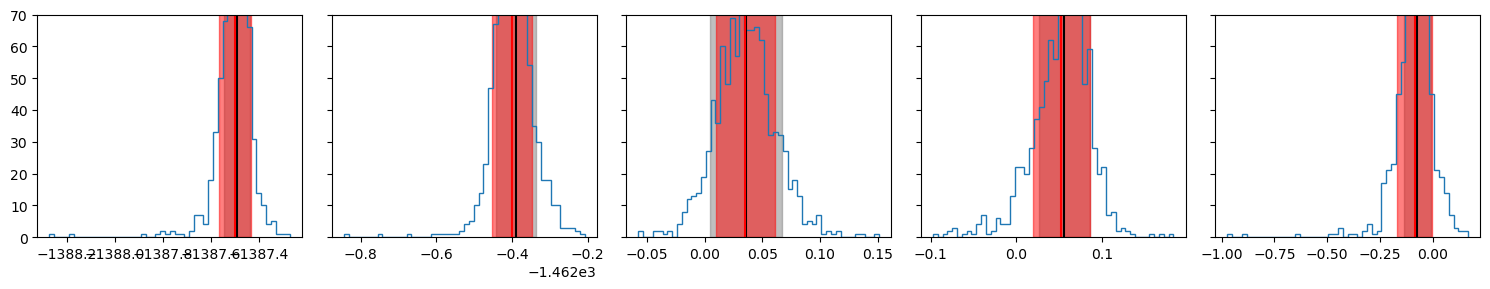

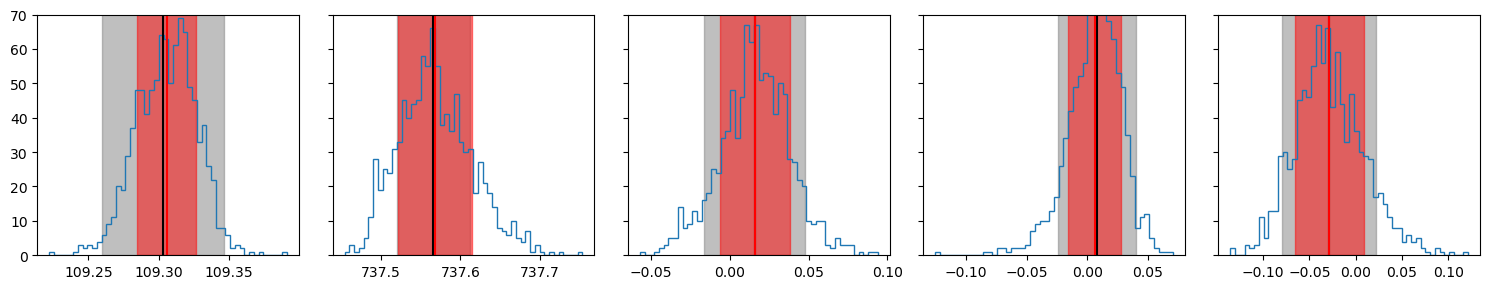

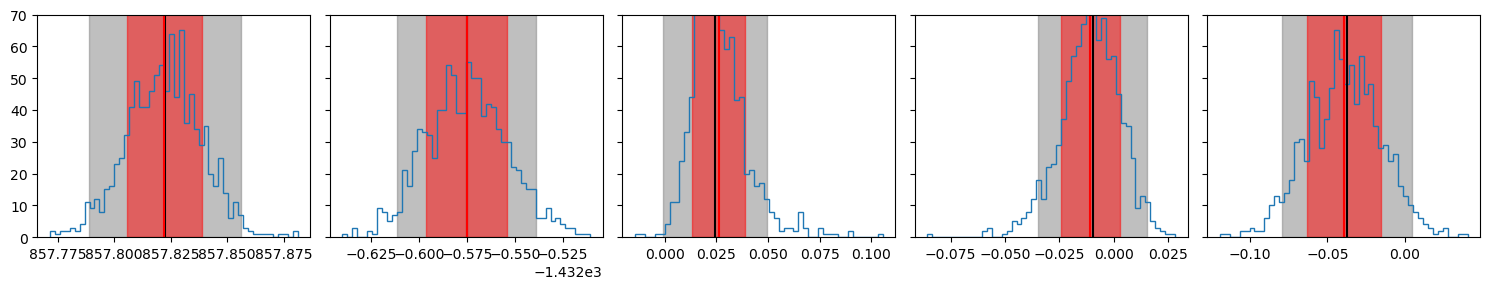

In [3]:
import sys

sys.path.append("/home/vwetzell/gitrepos/highpm/highpm")
from pmfit import singleFit, err2cov

degree = 3600.0
day = 1.0 / 365.2425
mjd_ref = 57388.0

rng = np.random.default_rng(42)

n_movers = 10000
n_movers = min(n_movers, len(movers))

true_p_arr = np.zeros((n_movers, 5))
true_p_std = np.zeros((n_movers, 5))
bootstrap_p_arr = np.zeros((n_movers, 5))
bootstrap_p_std = np.zeros((n_movers, 5))

mover_samples = rng.choice(movers["idx"], size=n_movers, replace=False)

for s, idx in enumerate(mover_samples):
    detections_for_mover = detections[detections["idx"] == idx]
    detections_for_mover = detections_for_mover[detections_for_mover["clipped"] == 0]
    detections_idx = detections_for_mover["detections"]

    temp_cat = slow_cat[detections_idx]

    xy = np.array([temp_cat["XI"], temp_cat["ETA"]]).T * degree
    t = (np.array(temp_cat["MJD"]) - mjd_ref) * day
    par_xy = np.array([temp_cat["PAR_XI"], temp_cat["PAR_ETA"]]).T
    
    # plt.figure()
    # plt.axis("equal")
    # plt.scatter(slow_cat["XI"]*degree, slow_cat["ETA"]*degree, s=1, c="grey", alpha=0.01)
    # plt.scatter(
    #     xy[:, 0],
    #     xy[:, 1],
    #     s=5,
    #     c=t,
    #     cmap="viridis",
    # )
    # plt.show()

    cov_xy = err2cov(temp_cat)

    p, fit, chisq, alpha = singleFit(
        xy,
        cov_xy,
        t,
        par_xy,
        # parallax_prior=1e-5,
        # pm_prior=0.005,
    )

    bootstrap_p_temp = np.zeros((1000, 5))
    temp_idx = np.arange(len(xy))
    for i in range(1000):
        bootstrap_idx = rng.choice(temp_idx, size=len(temp_idx), replace=True)
        bootstrap_xy = xy[bootstrap_idx]
        bootstrap_cov_xy = cov_xy[bootstrap_idx]
        bootstrap_t = t[bootstrap_idx]
        bootstrap_par_xy = par_xy[bootstrap_idx]

        try:
            bootstrap_p, _, _, _ = singleFit(
                bootstrap_xy,
                bootstrap_cov_xy,
                bootstrap_t,
                bootstrap_par_xy,
                # parallax_prior=1e-5,
                # pm_prior=0.005,
            )
        except np.linalg.LinAlgError:
            bootstrap_p = np.full(5, np.nan)

        bootstrap_p_temp[i] = bootstrap_p
        
    mean_p = np.mean(bootstrap_p_temp, axis=0)
    std_p = np.std(bootstrap_p_temp, axis=0)

    true_p_arr[s] = p
    true_p_std[s] = np.sqrt(np.diag(np.linalg.inv(alpha)))

    bootstrap_p_arr[s] = mean_p
    bootstrap_p_std[s] = std_p
    
    if s<5:
        fig,ax = plt.subplots(1, 5, figsize=(15, 3),sharey=True)
        ax[0].hist(bootstrap_p_temp[:, 0], bins=50, histtype="step",density=False) 
        ax[0].fill_betweenx(np.linspace(0,100,2),true_p_arr[s, 0] + true_p_std[s, 0],
                            true_p_arr[s, 0] - true_p_std[s, 0],
                            color='gray', alpha=0.5,) 
        ax[0].axvline(p[0], color='k')
        ax[0].fill_betweenx(np.linspace(0,100,2),bootstrap_p_arr[s, 0] + bootstrap_p_std[s, 0],
                            bootstrap_p_arr[s, 0] - bootstrap_p_std[s, 0],
                            color='red', alpha=0.5,)
        ax[0].axvline(bootstrap_p_arr[s, 0], color='red')
        ax[0].set_ylim(0,70)
        
        ax[1].hist(bootstrap_p_temp[:, 1], bins=50, histtype="step",density=False) 
        ax[1].fill_betweenx(np.linspace(0,100,2),true_p_arr[s, 1] + true_p_std[s, 1],
                            true_p_arr[s, 1] - true_p_std[s, 1],
                            color='gray', alpha=0.5,) 
        ax[1].axvline(p[1], color='k')
        ax[1].fill_betweenx(np.linspace(0,100,2),bootstrap_p_arr[s, 1] + bootstrap_p_std[s, 1],
                            bootstrap_p_arr[s, 1] - bootstrap_p_std[s, 1],
                            color='red', alpha=0.5,)
        ax[1].axvline(bootstrap_p_arr[s, 1], color='red')
        
        
        ax[2].hist(bootstrap_p_temp[:, 2], bins=50, histtype="step",density=False) 
        ax[2].fill_betweenx(np.linspace(0,100,2),true_p_arr[s, 2] + true_p_std[s, 2],
                            true_p_arr[s, 2] - true_p_std[s, 2],
                            color='gray', alpha=0.5,) 
        ax[2].axvline(p[2], color='k')
        ax[2].fill_betweenx(np.linspace(0,100,2),bootstrap_p_arr[s, 2] + bootstrap_p_std[s, 2],
                            bootstrap_p_arr[s, 2] - bootstrap_p_std[s, 2],
                            color='red', alpha=0.5,)
        ax[2].axvline(bootstrap_p_arr[s, 2], color='red')
        
        
        ax[3].hist(bootstrap_p_temp[:, 3], bins=50, histtype="step",density=False) 
        ax[3].fill_betweenx(np.linspace(0,100,2),true_p_arr[s, 3] + true_p_std[s, 3],
                            true_p_arr[s, 3] - true_p_std[s, 3],
                            color='gray', alpha=0.5,) 
        ax[3].axvline(p[3], color='k')
        ax[3].fill_betweenx(np.linspace(0,100,2),bootstrap_p_arr[s, 3] + bootstrap_p_std[s, 3],
                            bootstrap_p_arr[s, 3] - bootstrap_p_std[s, 3],
                            color='red', alpha=0.5,)
        ax[3].axvline(bootstrap_p_arr[s, 3], color='red')
        
        ax[4].hist(bootstrap_p_temp[:, 4], bins=50, histtype="step",density=False) 
        ax[4].fill_betweenx(np.linspace(0,100,2),true_p_arr[s, 4] + true_p_std[s, 4],
                            true_p_arr[s, 4] - true_p_std[s, 4],
                            color='gray', alpha=0.5,)
        ax[4].axvline(p[4], color='k')
        ax[4].fill_betweenx(np.linspace(0,100,2),bootstrap_p_arr[s, 4] + bootstrap_p_std[s, 4],
                            bootstrap_p_arr[s, 4] - bootstrap_p_std[s, 4],
                            color='red', alpha=0.5,)
        ax[4].axvline(bootstrap_p_arr[s, 4], color='red')
        
        plt.tight_layout()
        plt.show()

    

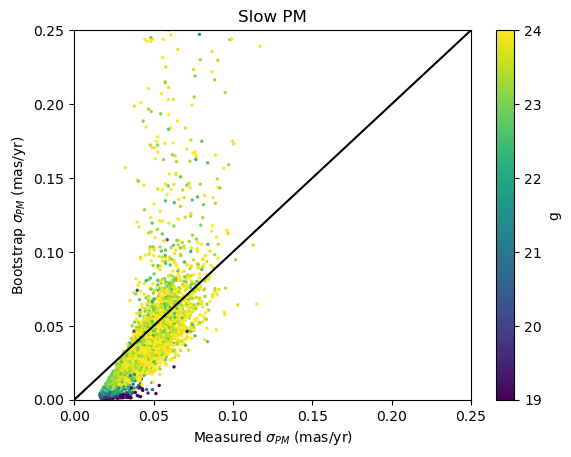

In [4]:
z = np.linspace(0, 0.25, 100)
plt.figure()
plt.title("Slow PM")
plt.scatter(
    np.hypot(true_p_std[:, 2], true_p_std[:, 3]),
    np.hypot(bootstrap_p_std[:, 2], bootstrap_p_std[:, 3]),
    s=2,
    c=movers["g_mag"][
        [np.argwhere(mover_sample == movers["idx"]) for mover_sample in mover_samples]
    ],
    vmin=19,
    vmax=24,
)
plt.colorbar(label="g")
plt.xlim(0.0, 0.25)
plt.ylim(0.0, 0.25)
plt.xlabel(r"Measured $\sigma_{PM}$ (mas/yr)")
plt.ylabel(r"Bootstrap $\sigma_{PM}$ (mas/yr)")
plt.plot(z, z, color="k")
plt.show()


In [ ]:

# plt.figure()
# plt.title("Slow PM Std in RA/Dec")
# plt.scatter(
#     np.sqrt(np.sum(true_p_std**2, axis=1)),
#     np.sqrt(np.sum(bootstrap_p_std**2, axis=1)),
#     s=2,
#     c=movers["g_mag"][
#         [np.argwhere(mover_sample == movers["idx"]) for mover_sample in mover_samples]
#     ],
#     vmin=19,
#     vmax=24,
# )
# plt.colorbar()
# plt.xlim(0.0, 0.2)
# plt.ylim(0.0, 0.2)
# plt.xlabel("Measured Std (mas/yr)")
# plt.ylabel("Bootstrap Std (mas/yr)")
# plt.plot(z, z, color="k")
# plt.show()

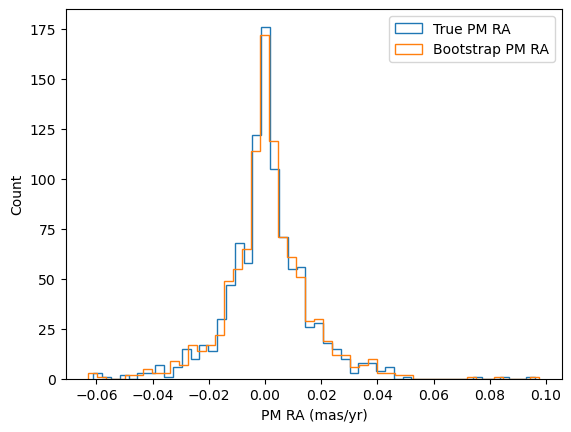

In [10]:
plt.figure()
plt.hist(true_p_arr[:, 2], bins=50, histtype="step", label="True PM RA")
plt.hist(bootstrap_p_arr[:, 2], bins=50, histtype="step", label="Bootstrap PM RA")
plt.xlabel("PM RA (mas/yr)")
plt.ylabel("Count")
plt.legend()
plt.show()